In [16]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
try:
    import torch
except ModuleNotFoundError:
    torch = None

from resources.MLmetrics import (
    postprocess_list_runs,
    postprocess_artifact_table,
    postprocess_load_curve_run,
    postprocess_curve_run_overview,
    display_curve_run_overview,
    postprocess_build_active_curve_diagnostics,
    curve_summary_table,
    display_curve_main_dashboard,
    display_curve_pointwise_summary,
    display_curve_sample_error_summary,
    display_curve_peak_energy_summary,
    display_curve_zone_summary,
    display_curve_sample_examples,
    display_curve_loss_component_breakdown,
    plot_curve_all_point_parity,
    display_curve_initial_slope_summary,
    plot_loss_history,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [17]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Find Recent Runs


In [18]:
FIND_RUN = False
RUN_ROOT = Path(r"Z:/p2")
MAX_RECENT_RUNS = 25


if FIND_RUN:
    recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=MAX_RECENT_RUNS, include_hpo=True)
    display(recent_runs)
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")


## 2. User Configuration


In [19]:
mechMode = "UT"
output_kind = "FieldToCurve"
model = "Transformer"
run_name = f"f2c{mechMode}full-fHPO"
VIEW_MODE = mechMode
run_type = "full_hpo" if "fHPO" in run_name else "model_hpo" if "mHPO" in run_name else "standard"  # "standard", "model_hpo", or "full_hpo"
ACTIVE_SPLIT = "test" if run_type.lower() == "standard" else "val"
RUN_PATH_OVERRIDE = None


if RUN_PATH_OVERRIDE is not None:
    RUN_PATH = Path(RUN_PATH_OVERRIDE)
elif run_type == "standard":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / run_name
elif run_type == "model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / "HPO" / run_name
elif run_type == "full_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / "HPO" / run_name / model
else:
    raise ValueError("run_type must be 'standard', 'model_hpo', or 'full_hpo'.")

DATA_PATH_OVERRIDE = None
PREFER_HPO_BEST = True
ZONE_BOUNDARIES = None

if VIEW_MODE is None:
    VIEW_MODE = mechMode if str(mechMode).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

## 3. Load Run Artifacts


In [20]:
LOAD_DATA = False
LOAD_MODEL = False

ARTIFACT_TABLE_KEYS = None

artifacts, loaded, DAT, MOD = postprocess_load_curve_run(
    RUN_PATH,
    run_root=RUN_ROOT,
    prefer_hpo_best=PREFER_HPO_BEST,
    load_data=LOAD_DATA,
    load_model=LOAD_MODEL,
    data_path_override=DATA_PATH_OVERRIDE,
    device=DEVICE,
)


display(postprocess_artifact_table(artifacts, keys=ARTIFACT_TABLE_KEYS))
for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)


,artifact,path_or_value
0,input_path,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
1,run_dir,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
2,model_json,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
3,model_mdl,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
4,data_json,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
5,results_dir,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
6,metrics_json,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
7,predictions_npz,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
8,loss_history_csv,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...
9,diagnostics_summary_json,Z:\p2\UT\FieldToCurve\HPO\f2cUTfull-fHPO\Trans...


## 4. Run Setup And Available Outputs


In [21]:
SHOW_RUN_OVERVIEW = False


overview = postprocess_curve_run_overview(
    artifacts,
    loaded,
    data=DAT,
    run_name=run_name,
    run_type=run_type,
    mech_mode=mechMode,
    view_mode=VIEW_MODE,
    model_name=model,
    device=DEVICE,
    active_split=ACTIVE_SPLIT,
)


available_evals = overview["available_evals"]
available_curve_evals = overview["available_curve_evals"]
ACTIVE_SPLIT = overview["active_split"]

if SHOW_RUN_OVERVIEW:
    display_curve_run_overview(overview)
print("mechMode:", mechMode)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)


mechMode: UT
VIEW_MODE: UT
ACTIVE_SPLIT: val


## 5. Build Active Curve Diagnostics


In [22]:
KEY_DIAGNOSTIC_METRICS = [
    "rmse",
    "mae",
    "bias",
    "nrmse_range",
    "r2_global",
    "collapse_ratio",
    "mean_curve_baseline_rmse",
    "skill_vs_mean_curve_rmse",
    "mean_sample_curve_corr",
    "peak_corr",
    "peak_x_corr",
    "energy_corr",
    "n_samples",
    "n_points",
]

DIAGNOSTIC_LABELS = {
    "rmse": "RMSE",
    "mae": "MAE",
    "bias": "bias",
    "nrmse_range": "NRMSE / range",
    "r2_global": "global R2",
    "collapse_ratio": "collapse ratio",
    "mean_curve_baseline_rmse": "mean-curve RMSE",
    "skill_vs_mean_curve_rmse": "skill vs mean curve",
    "mean_sample_curve_corr": "mean sample curve corr.",
    "peak_corr": "peak corr.",
    "peak_x_corr": "peak-x corr.",
    "energy_corr": "energy corr.",
    "n_samples": "samples",
    "n_points": "curve points",
}

ZONE_COLUMNS = {
    "zone": "zone",
    "x_start": "x start",
    "x_end": "x end",
    "rmse": "RMSE",
    "mae": "MAE",
    "collapse_ratio": "collapse ratio",
}


diagnostics, active_key, active_diag = postprocess_build_active_curve_diagnostics(
    DAT,
    loaded,
    available_evals,
    view_mode=VIEW_MODE,
    active_split=ACTIVE_SPLIT,
    model=MOD,
    zone_boundaries=ZONE_BOUNDARIES,
)


if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
else:
    display(Markdown(f"**Active diagnostics:** `{active_key[0]} {active_key[1].upper()}`"))

    summary_table = curve_summary_table(active_diag, metrics=KEY_DIAGNOSTIC_METRICS).copy()
    summary_table["metric"] = summary_table["metric"].replace(DIAGNOSTIC_LABELS)
    summary_table["value"] = summary_table["value"].map(
        lambda value: f"{value:.4g}"
        if isinstance(value, (int, float, np.integer, np.floating)) and np.isfinite(value)
        else value
    )
    display(summary_table)

    zone_table = active_diag.get("zone_metrics")
    if zone_table is not None and not zone_table.empty:
        display(Markdown("**Zone diagnostics**"))
        zone_table = zone_table[list(ZONE_COLUMNS)].rename(columns=ZONE_COLUMNS).copy()
        zone_table["zone"] = zone_table["zone"].str.replace("_", " ").str.title()
        for column in ["x start", "x end", "RMSE", "MAE", "collapse ratio"]:
            zone_table[column] = zone_table[column].map(lambda value: f"{value:.4g}" if pd.notna(value) else value)
        display(zone_table)


**Active diagnostics:** `UT VAL`

,metric,value
0,RMSE,1.562
1,MAE,0.9059
2,bias,-0.003959
3,NRMSE / range,0.0252
4,global R2,0.9955
5,collapse ratio,0.957
6,mean-curve RMSE,4.57
7,skill vs mean curve,0.6581
8,mean sample curve corr.,0.9979
9,peak corr.,0.7398


**Zone diagnostics**

,zone,x start,x end,RMSE,MAE,collapse ratio
0,Elastic,0,0.0198,0.5308,0.2477,0.8538
1,Peak Region,0.0201,0.03985,2.46,1.757,0.9674
2,Post Peak,0.04015,0.05994,0.994,0.7126,0.9511


## 6. Main Curve Diagnostic Dashboard


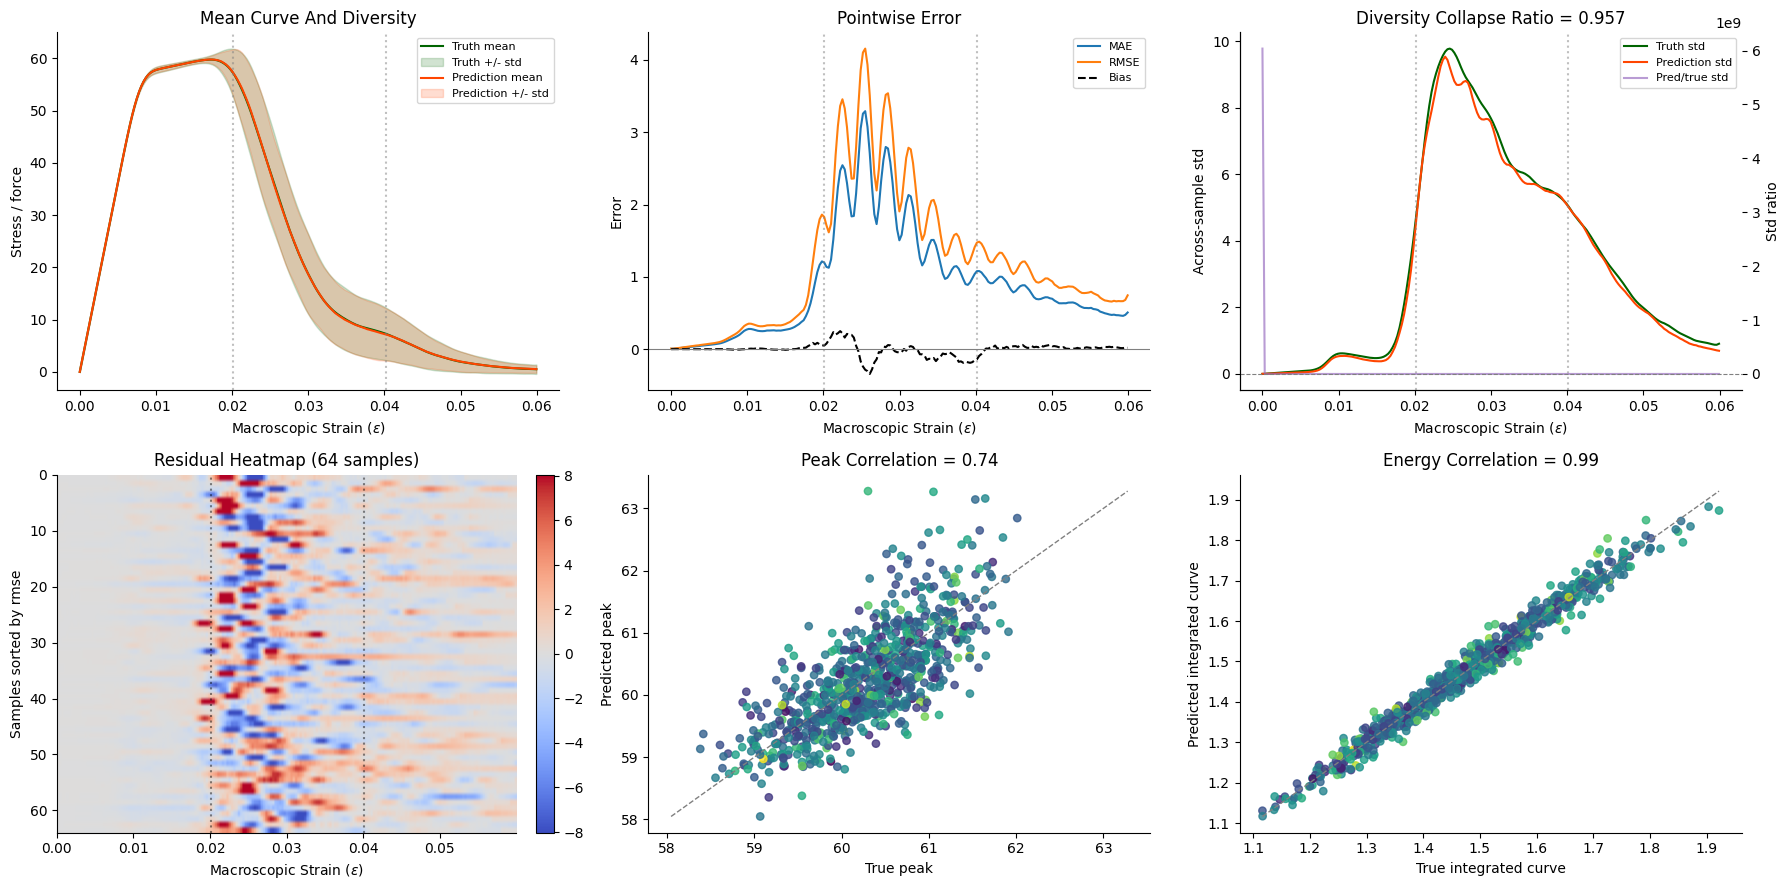

(<Figure size 1800x900 with 8 Axes>,
 array([[<Axes: title={'center': 'Mean Curve And Diversity'}, xlabel='Macroscopic Strain ($\\epsilon$)', ylabel='Stress / force'>,
         <Axes: title={'center': 'Pointwise Error'}, xlabel='Macroscopic Strain ($\\epsilon$)', ylabel='Error'>,
         <Axes: title={'center': 'Diversity Collapse Ratio = 0.957'}, xlabel='Macroscopic Strain ($\\epsilon$)', ylabel='Across-sample std'>],
        [<Axes: title={'center': 'Residual Heatmap (64 samples)'}, xlabel='Macroscopic Strain ($\\epsilon$)', ylabel='Samples sorted by rmse'>,
         <Axes: title={'center': 'Peak Correlation = 0.74'}, xlabel='True peak', ylabel='Predicted peak'>,
         <Axes: title={'center': 'Energy Correlation = 0.99'}, xlabel='True integrated curve', ylabel='Predicted integrated curve'>]],
       dtype=object))

In [23]:
DASHBOARD_MAX_SAMPLES = 64
DASHBOARD_SORT_BY = "rmse"


display_curve_main_dashboard(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_samples=DASHBOARD_MAX_SAMPLES,
    sort_by=DASHBOARD_SORT_BY,
)


## 7. Pointwise Error And Correlations


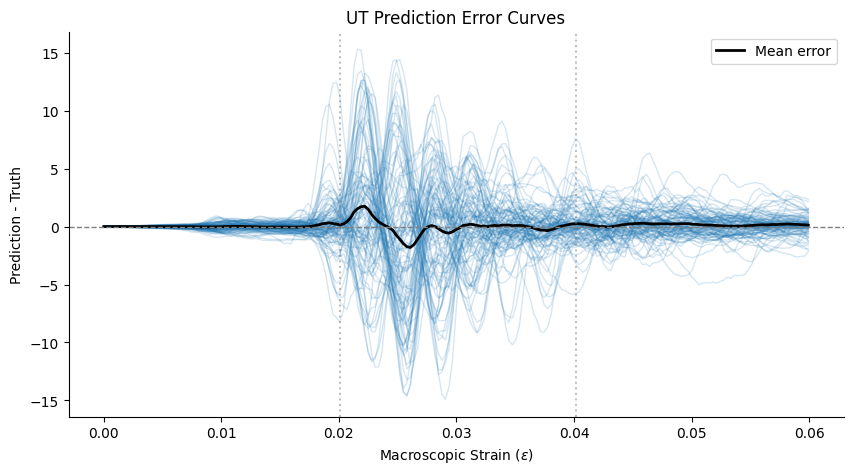

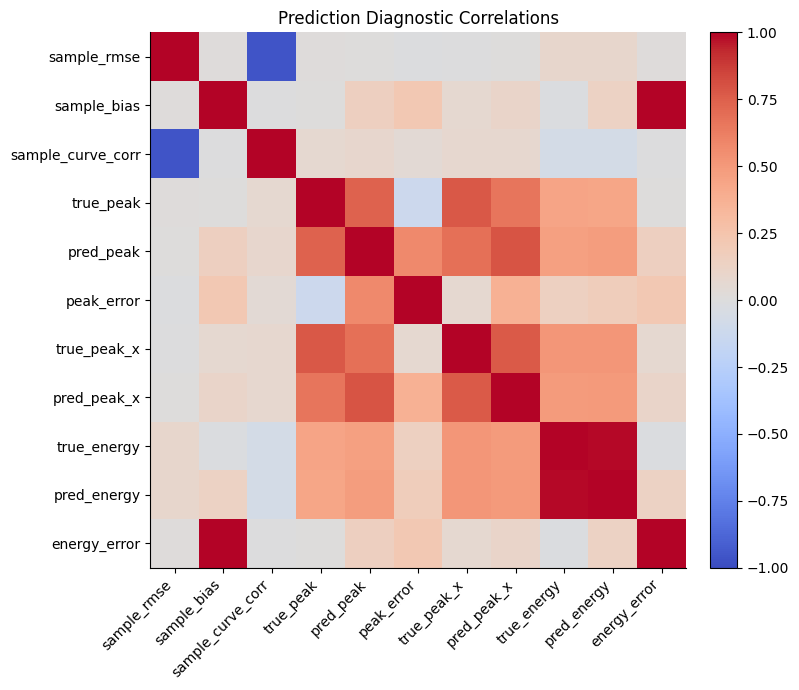

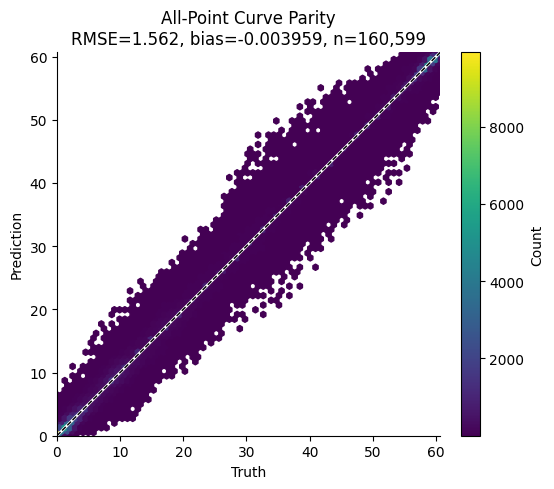

In [24]:
ERROR_CURVE_SAMPLES = 100
ERROR_CURVE_SORT_BY = "rmse"
SHOW_CORRELATION_MATRIX = True
SHOW_CURVE_PARITY = True
CURVE_PARITY_GRIDSIZE = 75
CURVE_PARITY_FIGSIZE = (6, 5)


display_curve_pointwise_summary(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_error_curves=ERROR_CURVE_SAMPLES,
    sort_by=ERROR_CURVE_SORT_BY,
    show_correlation=SHOW_CORRELATION_MATRIX,
)

if SHOW_CURVE_PARITY:
    plot_curve_all_point_parity(
        active_diag,
        gridsize=CURVE_PARITY_GRIDSIZE,
        figsize=CURVE_PARITY_FIGSIZE,
    )


## 8. Sample-Level Error


### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,sample_max_abs_error,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,peak_x_error,true_energy,pred_energy,energy_error
1,1,0.483377,0.417309,0.645995,-0.079706,1.943996,0.999579,59.876915,58.929634,-0.947282,0.016499,0.015599,-0.0009,1.408730,1.403955,-0.004775
418,418,0.428557,0.469639,0.685302,-0.016438,2.292768,0.999587,60.511633,60.526567,0.014934,0.019199,0.018899,-0.0003,1.442403,1.441413,-0.000990
103,103,0.498387,0.548669,0.740722,0.069176,2.837958,0.999580,59.644664,59.999332,0.354668,0.017699,0.017699,0.0000,1.346315,1.350462,0.004147
595,595,0.463957,0.550075,0.741671,0.224521,3.643892,0.999545,59.357308,59.731400,0.374092,0.015299,0.018599,0.0033,1.464952,1.478456,0.013504
56,56,0.474330,0.556885,0.746247,0.040428,3.419700,0.999527,60.808892,59.938267,-0.870625,0.018599,0.017099,-0.0015,1.287355,1.289783,0.002429
258,258,1.291804,6.923972,2.631344,0.098319,13.440091,0.993862,61.464943,60.624392,-0.840551,0.018599,0.019199,0.0006,1.385662,1.391556,0.005894
109,109,1.180821,7.015064,2.648597,-0.638648,14.592660,0.993549,60.025117,59.424366,-0.600751,0.015299,0.014999,-0.0003,1.281164,1.242643,-0.038521
718,718,1.539530,7.080344,2.660892,0.046136,12.781902,0.993255,60.047633,59.850141,-0.197491,0.018299,0.017399,-0.0009,1.656900,1.659579,0.002679
83,83,1.223092,7.285623,2.699189,0.642729,14.414226,0.993647,60.520466,60.179148,-0.341319,0.018899,0.016799,-0.0021,1.572064,1.610701,0.038637
436,436,1.226204,8.267296,2.875291,0.072252,13.209205,0.992175,59.102682,58.971225,-0.131457,0.014699,0.015899,0.0012,1.276752,1.281145,0.004392


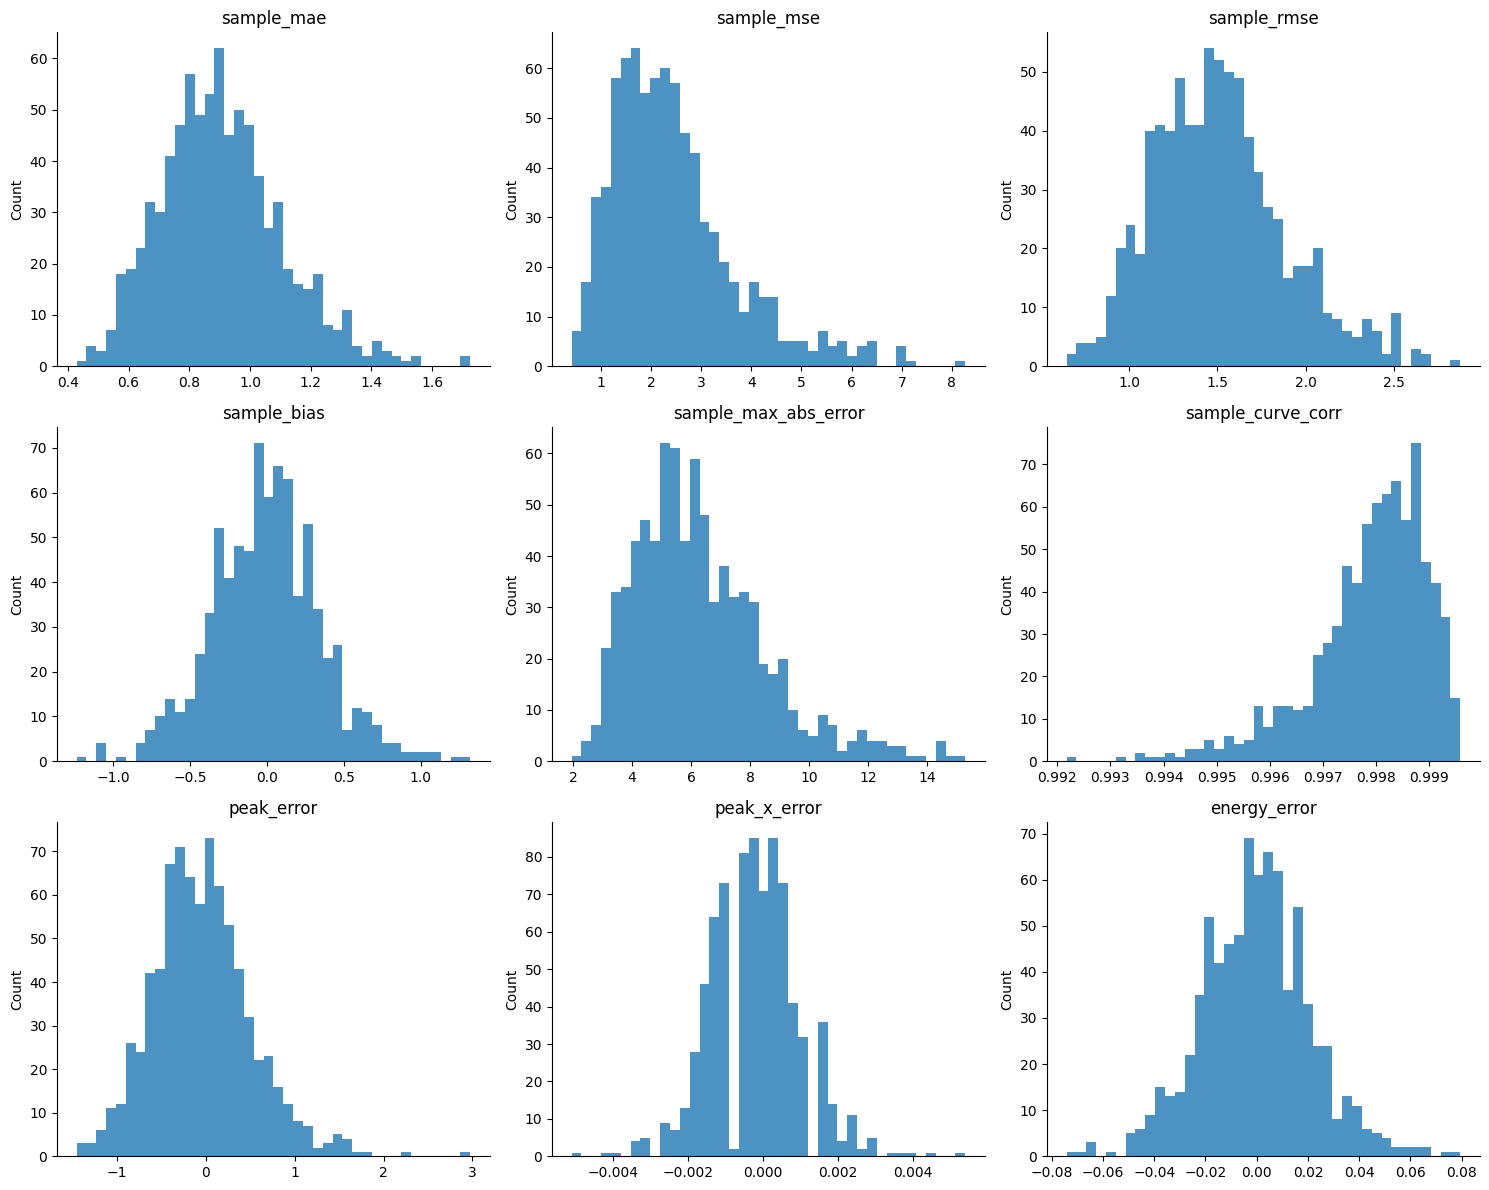

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,799.0,0.905907,0.200616,0.428557,0.772312,0.887783,1.020236,1.725860
sample_mse,799.0,2.441263,1.243098,0.417309,1.551458,2.205348,2.977098,8.267296
sample_rmse,799.0,1.516113,0.377945,0.645995,1.245575,1.485042,1.725427,2.875291
sample_bias,799.0,-0.003959,0.356405,-1.238622,-0.237240,-0.004650,0.219947,1.322123
sample_max_abs_error,799.0,6.297838,2.253285,1.943996,4.684773,5.936644,7.502876,15.307535
sample_curve_corr,799.0,0.997887,0.001113,0.992175,0.997402,0.998098,0.998691,0.999587
peak_error,799.0,-0.037760,0.554721,-1.449476,-0.408187,-0.054682,0.282521,2.975547
peak_x_error,799.0,-0.000185,0.001193,-0.005094,-0.000900,-0.000300,0.000600,0.005398
energy_error,799.0,-0.000239,0.021416,-0.074175,-0.014243,-0.000246,0.013154,0.079447


In [25]:
SAMPLE_DISTRIBUTION_BINS = 40
SAMPLE_DISTRIBUTION_NCOLS = 3
SAMPLE_TABLE_TOP_N = 5
SAMPLE_DESCRIBE_COLUMNS = [
    "sample_mae",
    "sample_mse",
    "sample_rmse",
    "sample_bias",
    "sample_max_abs_error",
    "sample_curve_corr",
    "peak_error",
    "peak_x_error",
    "energy_error",
]


display_curve_sample_error_summary(
    active_diag,
    bins=SAMPLE_DISTRIBUTION_BINS,
    ncols=SAMPLE_DISTRIBUTION_NCOLS,
    top_n=SAMPLE_TABLE_TOP_N,
    columns=SAMPLE_DESCRIBE_COLUMNS,
)


## 9. Initial Slope, Peak, And Energy Agreement


### Initial Slope Summary

,metric,value
0,window_start_idx,0.000000
1,window_end_idx,16.000000
2,window_start_x,0.000000
3,window_end_x,0.004800
4,window_points,17.000000
5,slope_correlation,0.400727
6,slope_mae,11.772093
7,slope_rmse,14.586156
8,slope_bias,-0.204881
9,slope_median_abs_percent_error,0.138375


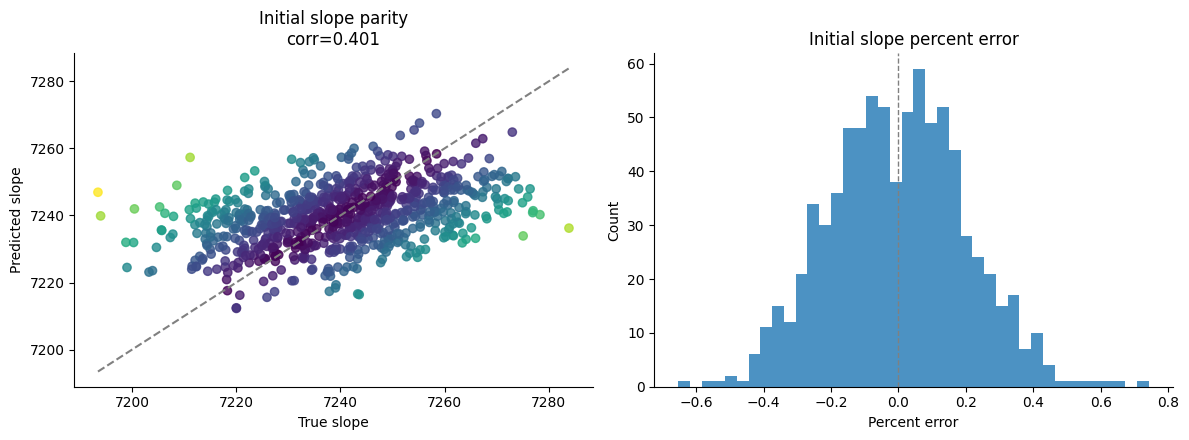

### Worst Initial Slope Samples

,sample,true_slope,pred_slope,slope_error,slope_percent_error,abs_percent_error
543,543,7193.471732,7246.916855,53.445124,0.742967,0.742967
252,252,7283.855737,7236.224179,-47.631558,-0.653933,0.653933
745,745,7211.154125,7257.298823,46.144699,0.639907,0.639907
405,405,7193.985697,7239.869512,45.883816,0.637808,0.637808
508,508,7200.470637,7241.952571,41.481934,0.576100,0.576100


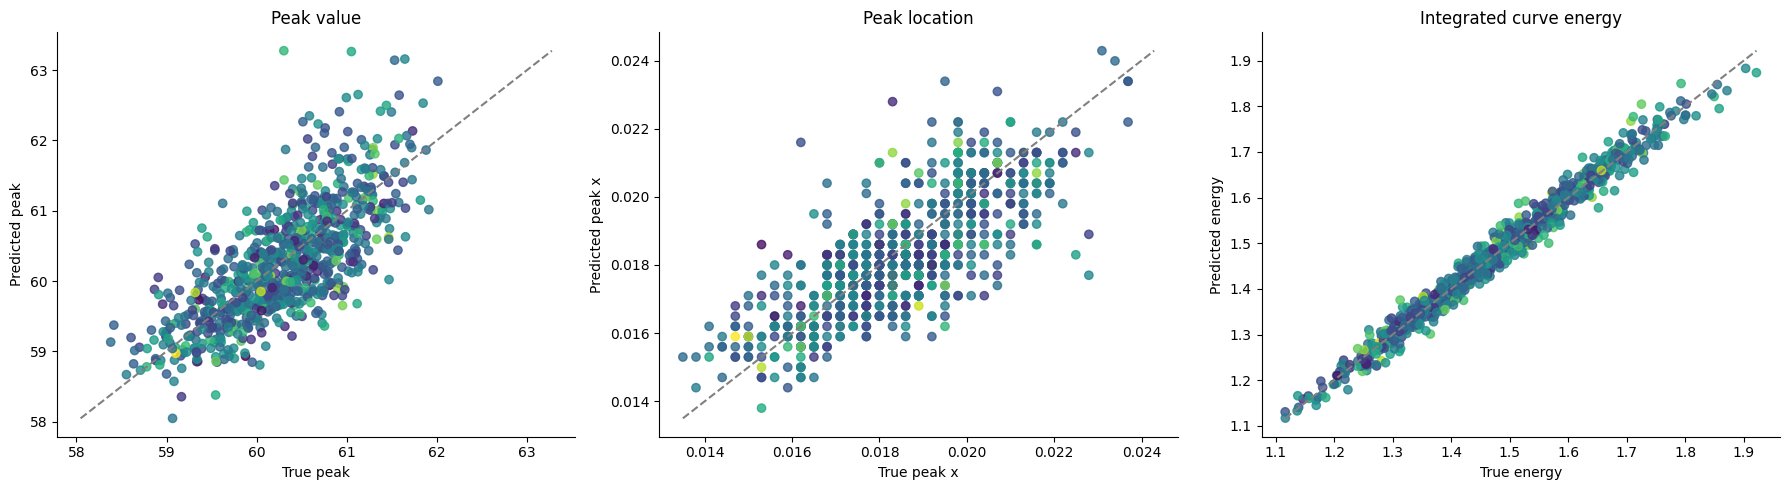

In [26]:
SHOW_INITIAL_SLOPE = True
INITIAL_SLOPE_WINDOW_FRACTION = 0.08
INITIAL_SLOPE_X_THRESHOLD = None
INITIAL_SLOPE_MIN_POINTS = 3
INITIAL_SLOPE_TOP_N = 5
SHOW_PEAK_ENERGY = True


if SHOW_INITIAL_SLOPE:
    slope_metrics_df, slope_summary = display_curve_initial_slope_summary(
        active_diag,
        window_fraction=INITIAL_SLOPE_WINDOW_FRACTION,
        x_threshold=INITIAL_SLOPE_X_THRESHOLD,
        min_points=INITIAL_SLOPE_MIN_POINTS,
        top_n=INITIAL_SLOPE_TOP_N,
    )

if SHOW_PEAK_ENERGY:
    display_curve_peak_energy_summary(active_diag)


## 10. Zone Metrics


### Zone Metrics

,zone,start_idx,end_idx,x_start,x_end,mae,mse,rmse,bias,true_std_mean,pred_std_mean,collapse_ratio
0,elastic,0,67,0.000000,0.019799,0.247736,0.281767,0.530817,0.007060,0.581208,0.496223,0.853779
1,peak_region,67,134,0.020099,0.039848,1.757419,6.054041,2.460496,-0.038188,7.206080,6.970803,0.967350
2,post_peak,134,201,0.040147,0.059936,0.712566,0.987981,0.993973,0.019251,2.374975,2.258747,0.951061


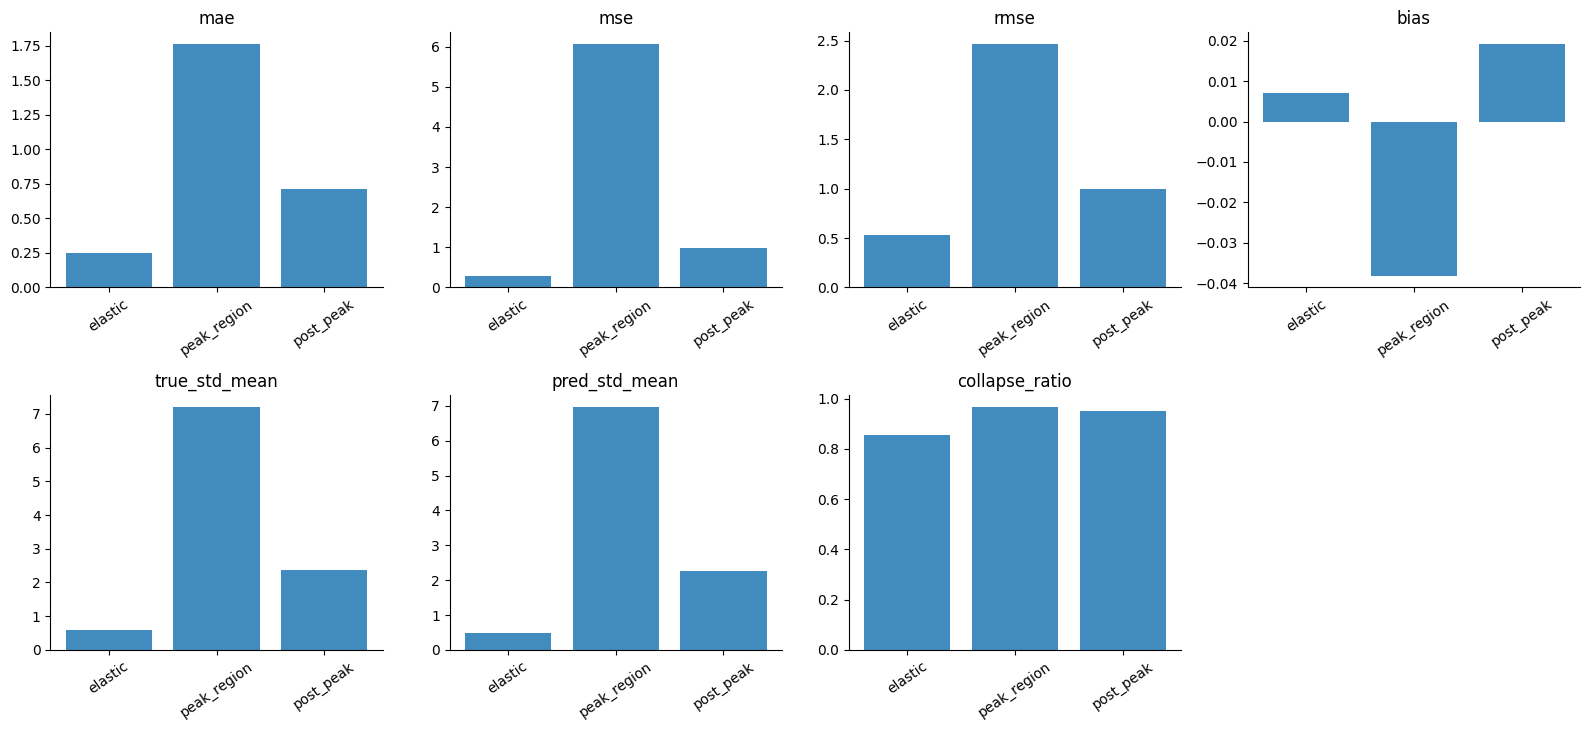

In [27]:
SHOW_ZONE_METRICS = True


if SHOW_ZONE_METRICS:
    display_curve_zone_summary(active_diag)


## 11. Selected Curve Examples


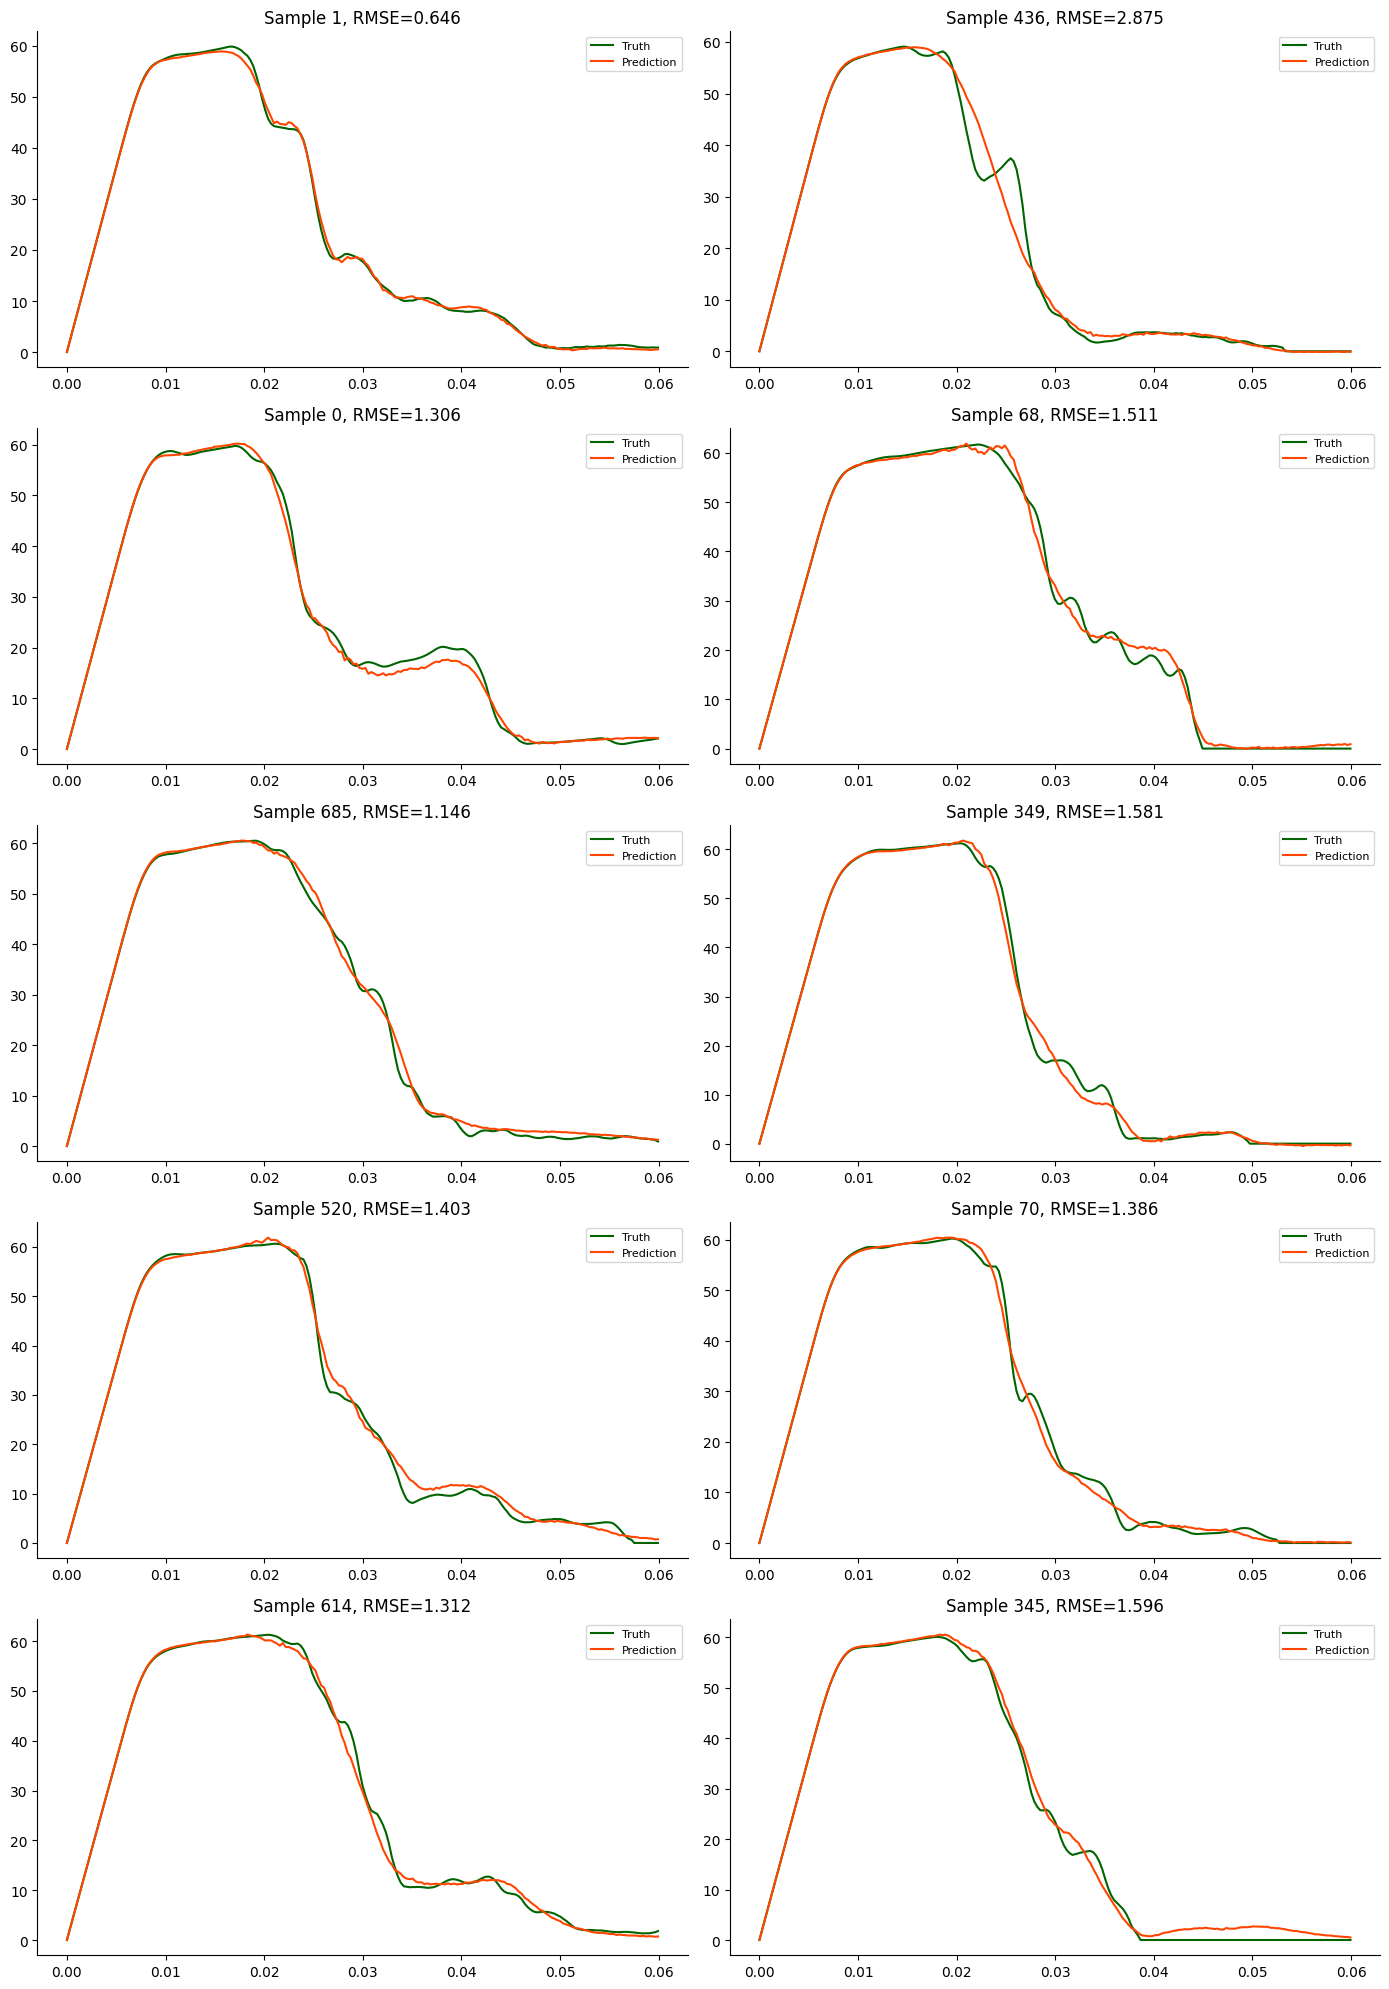

(<Figure size 1400x2000 with 10 Axes>,
 array([<Axes: title={'center': 'Sample 1, RMSE=0.646'}>,
        <Axes: title={'center': 'Sample 436, RMSE=2.875'}>,
        <Axes: title={'center': 'Sample 0, RMSE=1.306'}>,
        <Axes: title={'center': 'Sample 68, RMSE=1.511'}>,
        <Axes: title={'center': 'Sample 685, RMSE=1.146'}>,
        <Axes: title={'center': 'Sample 349, RMSE=1.581'}>,
        <Axes: title={'center': 'Sample 520, RMSE=1.403'}>,
        <Axes: title={'center': 'Sample 70, RMSE=1.386'}>,
        <Axes: title={'center': 'Sample 614, RMSE=1.312'}>,
        <Axes: title={'center': 'Sample 345, RMSE=1.596'}>], dtype=object))

In [28]:
SELECTED_SAMPLE = 0
RANDOM_SAMPLE_COUNT = 7
RANDOM_SEED = 42
EXAMPLE_RANK_BY = "sample_rmse"
EXAMPLE_NCOLS = 2


display_curve_sample_examples(
    active_diag,
    selected_sample=SELECTED_SAMPLE,
    random_count=RANDOM_SAMPLE_COUNT,
    random_seed=RANDOM_SEED,
    rank_by=EXAMPLE_RANK_BY,
    ncols=EXAMPLE_NCOLS,
)


## 12. Training Loss History


,mode,epoch,train_loss,val_loss
0,UT,1,0.115582,0.055945
1,UT,2,0.059802,0.043655
2,UT,3,0.047533,0.036436
3,UT,4,0.041883,0.033237
4,UT,5,0.038737,0.033213


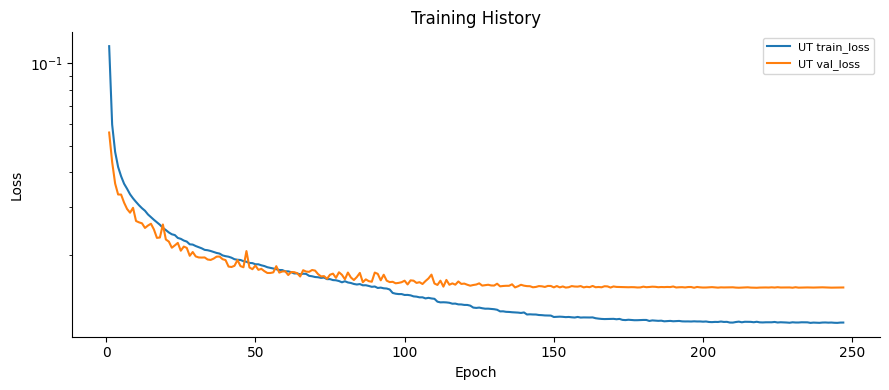

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Training History'}, xlabel='Epoch', ylabel='Loss'>)

In [29]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is not None and hasattr(loss_history, "empty") and not loss_history.empty:
    display(loss_history.head())
plot_loss_history(loss_history, metrics=LOSS_HISTORY_METRICS, figsize=LOSS_HISTORY_FIGSIZE)


## 13. Loss Component Breakdown


In [30]:
SHOW_LOSS_COMPONENTS = True


if SHOW_LOSS_COMPONENTS:
    loss_components_df = display_curve_loss_component_breakdown(MOD, active_diag, active_key=active_key)


MODEL is not loaded, so loss components cannot be evaluated.
